# Eksperyment: Wpływ Architektury (Warstwy i Neurony) na Wyniki MLP

W tym notatniku zbadano, jak zmiana liczby warstw ukrytych i neuronów wpływa na proces uczenia i ostateczną wydajność modelu MLP w zadaniu klasyfikacji wieloklasowej (5 klas, dane nieliniowe).

Wykorzystujemy najlepszą funkcję aktywacji (GELU) z poprzedniego eksperymentu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.f2py.crackfortran import verbose

from mlp import MLP
from mlp.utils import plot_loss, plot_weight_evolution, plot_dataset, plot_decision_boundary, train_test_split, accuracy, mse, plot_predictions,load_dataset, plot_accuracy, plot_weights_together

# Konfiguracja bazowa
SEED = 44
np.random.seed(SEED)

# Ustaw ścieżkę do pliku CSV
# Upewnij się, że ten plik jest dostępny (np. w folderze '../lab1_data/Classification/')
CSV_PATH = "../lab1_data/Regression/data.activation.train.1000.csv" 
TASK = "regression"
ACTIVATION = "gelu" 
LEARNING_RATE = 0.05
EPOCHS = 100
USE_BIAS = True

# Wczytanie i przygotowanie danych
X, y = load_dataset(CSV_PATH)

N_FEATURES = X.shape[1]
N_CLASSES = len(np.unique(y))
Y_TARGET = y.reshape(-1, 1) # Używamy Y_TARGET w fit/loss, ale X, y w plotach
print(f"Dane wczytane. Cechy: {N_FEATURES}, Klasy: {N_CLASSES}")
print(f"Przykładowe etykiety: {np.unique(y)}")

[load_dataset] Detected REGRESSION: normalized target (mean=-93.366, std=89.163)
Dane wczytane. Cechy: 1, Klasy: 1000
Przykładowe etykiety: [-1.91433966 -1.91267196 -1.90304931 -1.89959385 -1.89864067 -1.89594952
 -1.89118569 -1.88906745 -1.88352483 -1.88320507 -1.8812293  -1.88032677
 -1.87790068 -1.86755905 -1.86672484 -1.86189686 -1.86129837 -1.86101955
 -1.86062124 -1.85812189 -1.85592214 -1.85467359 -1.84992047 -1.84984547
 -1.84687359 -1.84614997 -1.84242975 -1.84097772 -1.83757034 -1.83356749
 -1.83305521 -1.83121847 -1.82977527 -1.82565417 -1.82459424 -1.82224501
 -1.82067647 -1.81811239 -1.81715461 -1.81467231 -1.81149992 -1.80248093
 -1.80195148 -1.80178886 -1.80106699 -1.79644006 -1.79606812 -1.79466133
 -1.7935394  -1.79165144 -1.78980859 -1.78853032 -1.78700479 -1.77893362
 -1.75253059 -1.74394362 -1.7431919  -1.74163083 -1.73665991 -1.73597084
 -1.73403861 -1.73113946 -1.730891   -1.73072024 -1.71987281 -1.71747849
 -1.71179547 -1.70680593 -1.70644031 -1.70271312 -1.69759

## Wizualizacja Danych

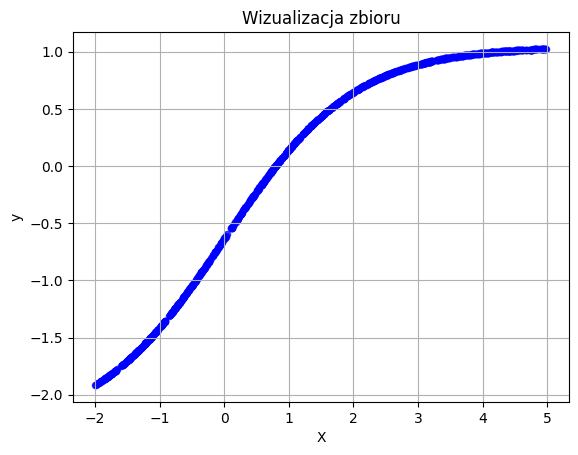

In [2]:
plot_dataset(X,y,"Wizualizacja zbioru")

## Konfiguracja i Trening Eksperymentów

In [ ]:
# Eksperymentalne architektury do porównania
# Format: { Nazwa: [Rozmiary Warstw] }
ARCHITECTURES = {
    # 1. Architektury Płytkie (Mniej warstw, różna liczba neuronów)
    "Shallow": [N_FEATURES,  N_CLASSES], 
    "Shallow_8": [N_FEATURES, 8, N_CLASSES],      
    "Shallow_16": [N_FEATURES, 16, N_CLASSES],     
    "Shallow_32": [N_FEATURES, 32, N_CLASSES],     
    # 2. Architektury Głębokie (Więcej warstw, podobna liczba neuronów)
    "Deep_8_8": [N_FEATURES, 8, 8, N_CLASSES],     
    "Deep_16_8": [N_FEATURES, 16, 8, N_CLASSES],   
    "Deep_16_16": [N_FEATURES, 16, 16, N_CLASSES],
    "Deep_32_64_64_32": [N_FEATURES, 32, 64, 64, 32, N_CLASSES],
    
}


X_train, X_test, y_train, y_test = train_test_split(X, y, test_ratio=0.3, seed=SEED)
all_results = {}
print("--- Rozpoczynanie eksperymentów architektonicznych ---")

for name, layer_sizes in ARCHITECTURES.items():
    print(f"\n=== Trening dla architektury: {name} ({layer_sizes}) ===")
    
    # Konfiguracja MLP (zakładamy, że TASK, ACTIVATION, LEARNING_RATE są zdefiniowane)
    model = MLP(
        layer_sizes=layer_sizes,
        task=TASK,
        activation=ACTIVATION,
        learning_rate=LEARNING_RATE,
        seed=SEED
    )

    # Trening
    losses, weight_hist, accuracy_history = model.fit(
        X_train, y_train, epochs=EPOCHS, verbose=False, one_hot_if_needed=True
    )
    
    # Predykcja i Metryka Testowa
    preds_raw = model.predict(X_test)

    if TASK == "regression":
        metric = mse(y_test, preds_raw) 
        metric_name = "MSE (TEST)"
    else:
        # DLA KLASYFIKACJI (BINARNEJ I WIELOKLASOWEJ):
        # 1. Konwersja surowych predykcji (N, N_CLASSES) na etykiety (N,) 
        preds_labels = np.argmax(preds_raw, axis=1)
        
        # 2. Obliczanie metryki (Accuracy)
        metric = accuracy(y_test, preds_labels)
        metric_name = "Dokładność (TEST)"

    # Zapisanie wyników
    all_results[name] = {
        "model": model,
        "layer_sizes": layer_sizes,
        "losses": losses,
        "weights": weight_hist,
        "accuracy": metric # Użycie 'accuracy' jako klucza, zgodnie z poprzednimi dyskusjami
    }

    print(f"Końcowa strata (trening): {losses[-1]:.6f} | {metric_name}: {metric:.4f}")

    # --- WIZUALIZACJE DLA KAŻDEJ ARCHITEKTURY (Krok 3) ---
    print("--- Generowanie wizualizacji ---")
    
    # 1. Wykres straty w czasie (zawsze)
    plot_loss(losses, title=f"Ewolucja straty: {name}")

    # 2. Tylko dla klasyfikacji (Accuracy, Decision Boundary)
    if TASK != "regression":
        
        # Wykres dokładności w czasie
        plot_accuracy(accuracy_history, title=f"Ewolucja dokładności: {name}")

        # Granica decyzyjna (używamy całego zbioru X/y, jak w Twoim wzorcu)
        # UWAGA: Użyj X_train lub X, w zależności od tego, co ma plot_decision_boundary
        plot_decision_boundary(
            model, X, y, # X i y - pełny zbiór (zakładamy, że jest to zbiór do wizualizacji)
            title=f"Granica decyzyjna: {name} (Test Acc: {metric:.3f})"
        )

    # 3. Wykres zmian wag (zawsze)
    plot_weights_together(weight_hist, title=f"Ewolucja norm wag: {name}")

print("\n--- Zakończono eksperymenty ---")

--- Rozpoczynanie eksperymentów architektonicznych ---

=== Trening dla architektury: Shallow ([1, 1000]) ===


ValueError: operands could not be broadcast together with shapes (300,) (300000,) 

## Wizualizacja Wyników

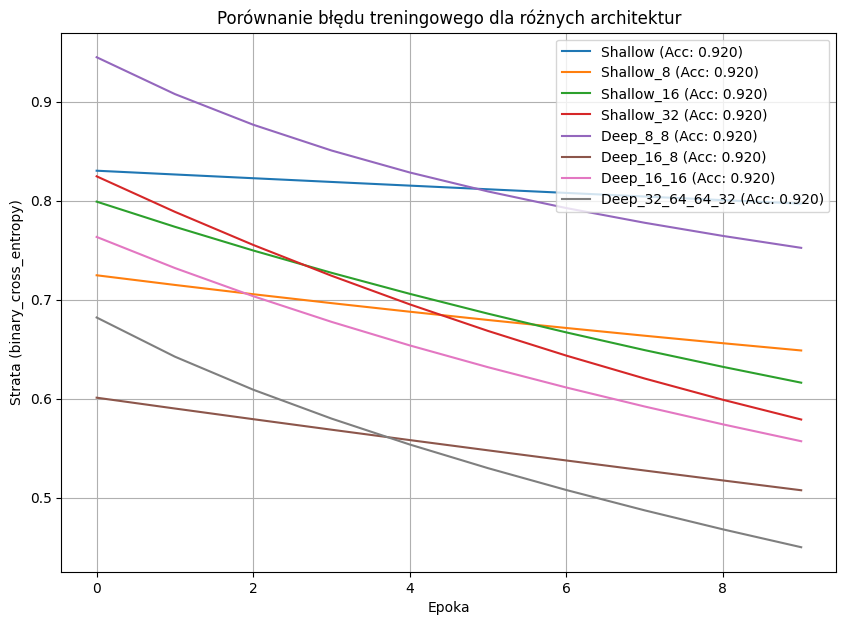


--- Wizualizacja wyników: Shallow ---


ValueError: cannot reshape array of size 80000 into shape (200,200)

In [ ]:
# --- 5.1. Porównanie krzywych błędu (Loss) ---
# ... (ten fragment już poprawiliśmy, używa 'accuracy' i jest ok)

# --- 5.2. Wizualizacja granic decyzyjnych i ewolucji wag ---
for name, res in all_results.items():
    print(f"\n--- Wizualizacja wyników: {name} ---")
    
    # Ewolucja wag (zawsze)
    plot_weights_together(
        res["weights"], 
        title=f"Ewolucja norm wag: {name}"
    )

    # Granice decyzyjne i inne wizualizacje (tylko dla 2D klasyfikacji)
    if TASK != "regression":
        # Granice decyzyjne
        if X.shape[1] == 2:
            plot_decision_boundary(
                res["model"], X, y, # Używamy pełnego zbioru X i y (nie Y_TARGET) do scatter plot w utils.py
                title=f"Granica decyzyjna: {name} (Acc: {res['accuracy']:.3f})"
            )
        else:
            print("Pominięto plot_decision_boundary: Wymaga 2 cech wejściowych.")
    
    # Wizualizacja dla Regresji 1D
    elif TASK == "regression" and X.shape[1] == 1:
        # Ponownie liczymy predykcje na zbiorze testowym do wyświetlenia
        preds_test = res["model"].predict(X_test)
        
        plot_predictions(
            y_test, preds_test, 
            title=f"Predykcje vs. Prawda: {name} (MSE: {res['accuracy']:.3f})"
        )